# Proyek Portofolio: Business Analytics
## Analisis Faktor Keterlambatan Pengiriman dan Dampaknya terhadap Kepuasan Pelanggan (Review Score)
Sumber Dataset: Brazilian E-Commerce Public Dataset by Olist

# Langkah 1: Persiapan Data (Pemuatan, Penggabungan, dan Pembersihan)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

orders_path = 'archive/olist_orders_dataset.csv'
reviews_path = 'archive/olist_order_reviews_dataset.csv'

df_orders = pd.read_csv(orders_path)
df_reviews = pd.read_csv(reviews_path)

print(f"Jumlah baris df_orders: {df_orders.shape[0]}")
print(f"Jumlah baris df_reviews: {df_reviews.shape[0]}")

df_merged = pd.merge(df_orders, df_reviews, on='order_id', how='inner')
print(f"\nJumlah baris setelah digabungkan: {df_merged.shape[0]}")

datetime_cols = [
    'order_purchase_timestamp', 
    'order_approved_at', 
    'order_delivered_carrier_date', 
    'order_delivered_customer_date', 
    'order_estimated_delivery_date',
    'review_creation_date',
    'review_answer_timestamp'
]

for col in datetime_cols:
    df_merged[col] = pd.to_datetime(df_merged[col])

print("\nNilai kosong per kolom:\n", df_merged.isnull().sum()[df_merged.isnull().sum() > 0])

df_clean = df_merged.dropna(subset=['order_delivered_customer_date']).copy()

print(f"\nJumlah baris setelah menghapus pesanan yang belum terkirim: {df_clean.shape[0]}")

print("\n5 baris pertama dari data yang sudah dibersihkan:")
df_clean.head()

Jumlah baris df_orders: 99441
Jumlah baris df_reviews: 99224

Jumlah baris setelah digabungkan: 99224

Nilai kosong per kolom:
 order_approved_at                  156
order_delivered_carrier_date      1756
order_delivered_customer_date     2865
review_comment_title             87656
review_comment_message           58247
dtype: int64

Jumlah baris setelah menghapus pesanan yang belum terkirim: 96359

5 baris pertama dari data yang sudah dibersihkan:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,359d03e676b3c069f62cadba8dd3f6e8,5,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,e50934924e227544ba8246aeb3770dd4,5,NaN,NaN,2018-02-17,2018-02-18 13:02:51


# Langkah 2: Analisis Data Eksploratif (EDA) dan Perhitungan Keterlambatan

Fokus analisis kita pada tahap ini:

1. **Menghitung Selisih Pengiriman** — Kita hitung durasi pengiriman aktual vs estimasi untuk menentukan status pengiriman (Tepat Waktu vs Terlambat).

2. **Distribusi Review Score** — Kita lihat persebaran skor ulasan dari pelanggan.

3. **Korelasi Status Pengiriman vs Review Score** — Kita bandingkan skor ulasan antara pesanan yang tepat waktu dan yang terlambat.

Proporsi Status Pengiriman:
 delivery_status
Tepat Waktu    93.347793
Terlambat       6.652207
Name: proportion, dtype: float64


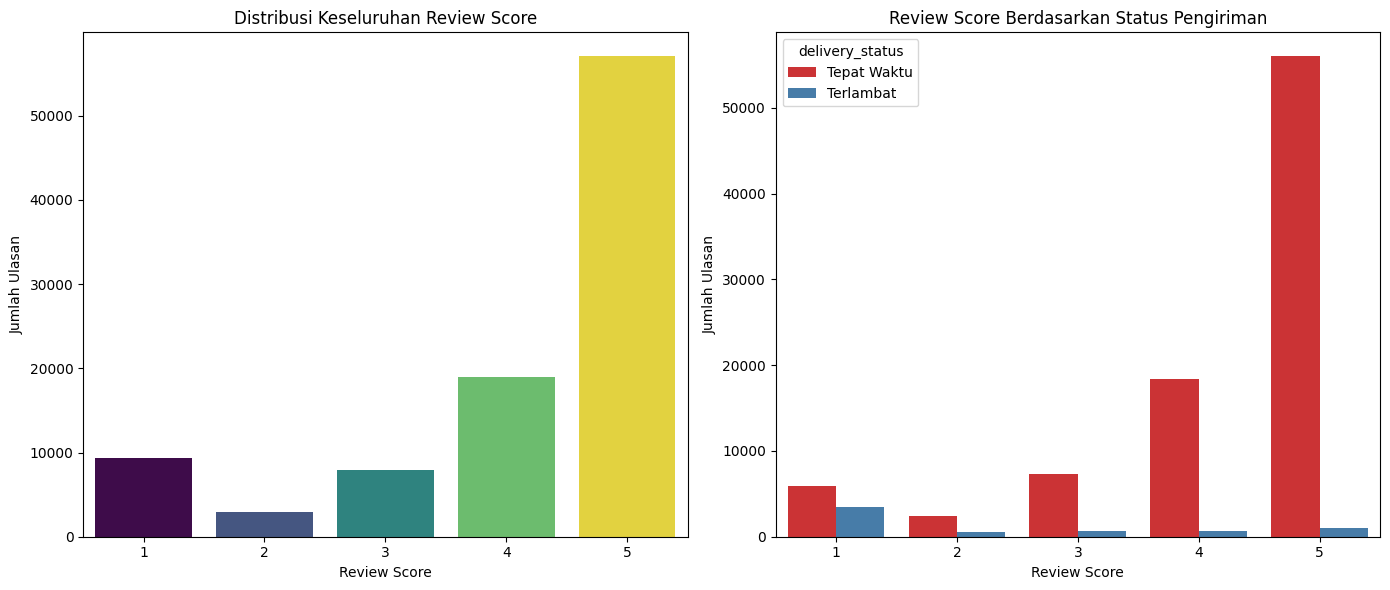


Rata-rata Review Score berdasarkan Status Pengiriman:
                 review_score
delivery_status              
Tepat Waktu              4.29
Terlambat                2.27


In [3]:

df_clean['delivery_delay_days'] = (df_clean['order_delivered_customer_date'] - df_clean['order_estimated_delivery_date']).dt.days

df_clean['delivery_status'] = np.where(df_clean['delivery_delay_days'] > 0, 'Terlambat', 'Tepat Waktu')

print("Proporsi Status Pengiriman:\n", df_clean['delivery_status'].value_counts(normalize=True) * 100)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.countplot(data=df_clean, x='review_score', hue='review_score', palette='viridis', legend=False)
plt.title('Distribusi Keseluruhan Review Score')
plt.xlabel('Review Score')
plt.ylabel('Jumlah Ulasan')

plt.subplot(1, 2, 2)
sns.countplot(data=df_clean, x='review_score', hue='delivery_status', palette='Set1')
plt.title('Review Score Berdasarkan Status Pengiriman')
plt.xlabel('Review Score')
plt.ylabel('Jumlah Ulasan')

plt.tight_layout()
plt.show()

print("\nRata-rata Review Score berdasarkan Status Pengiriman:")
print(df_clean.groupby('delivery_status')[['review_score']].mean().round(2))

# Langkah 3: Rekayasa Fitur & Akar Masalah Keterlambatan (Root Cause Analysis)

Mari kita bedah penyebab keterlambatan dengan menghitung dua metrik baru:
1. **Waktu Proses Penjual**: Berapa lama waktu yang dibutuhkan penjual untuk menyerahkan barang ke kurir sejak pesanan disetujui.
2. **Waktu Pengiriman Kurir**: Berapa lama waktu kurir mengirim barang ke pelanggan sejak menerima barang dari penjual.

Kita juga akan memuat dataset produk dan item pesanan untuk melihat apakah ada kategori produk tertentu yang lebih sering bermasalah.

Rata-rata Waktu (Hari) Berdasarkan Status Pengiriman:
                 seller_processing_days  courier_delivery_days
delivery_status                                               
Tepat Waktu                        2.15                   7.55
Terlambat                          5.05                  27.29


C:\Users\altha\AppData\Local\Temp\ipykernel_12592\3608789998.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_late_categories.values, y=top_late_categories.index, palette='Reds_r')


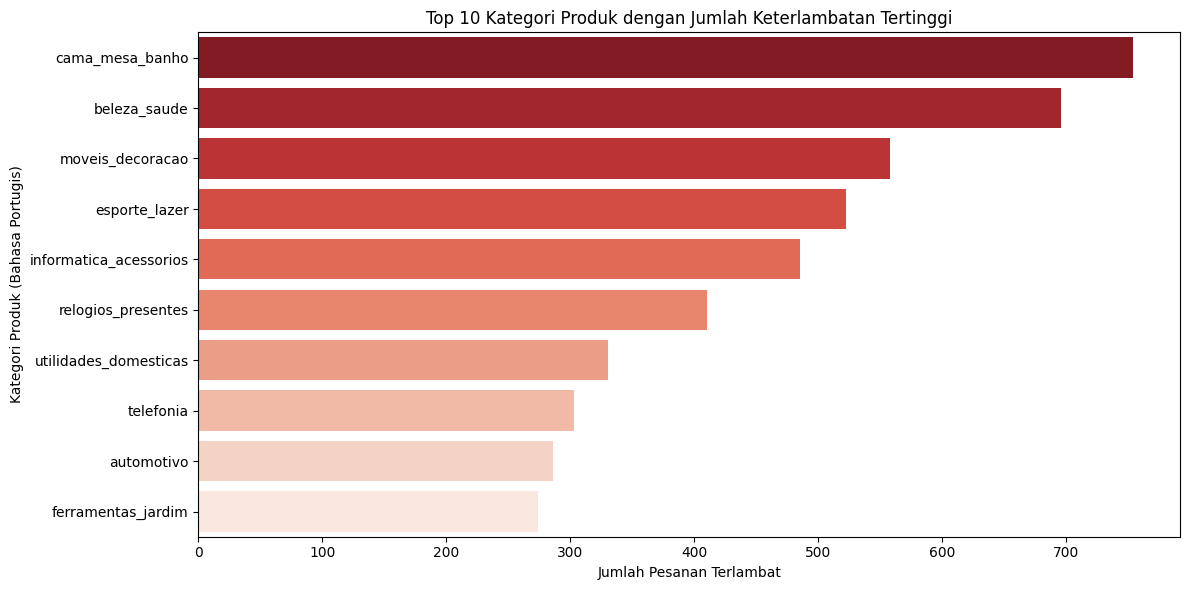

In [4]:
# 1. Menghitung Waktu Proses Penjual dan Waktu Kurir (dalam hari)
df_clean['seller_processing_days'] = (df_clean['order_delivered_carrier_date'] - df_clean['order_approved_at']).dt.days
df_clean['courier_delivery_days'] = (df_clean['order_delivered_customer_date'] - df_clean['order_delivered_carrier_date']).dt.days

# Menghapus nilai negatif anomali jika ada (kemungkinan kesalahan input data dari sistem logistik)
df_clean = df_clean[(df_clean['seller_processing_days'] >= 0) & (df_clean['courier_delivery_days'] >= 0)].copy()

# 2. Melihat rata-rata waktu berdasarkan status pengiriman
print("Rata-rata Waktu (Hari) Berdasarkan Status Pengiriman:")
print(df_clean.groupby('delivery_status')[['seller_processing_days', 'courier_delivery_days']].mean().round(2))

# 3. Memuat tabel tambahan untuk melihat kategori produk
items_path = 'archive/olist_order_items_dataset.csv'
products_path = 'archive/olist_products_dataset.csv'

df_items = pd.read_csv(items_path)
df_products = pd.read_csv(products_path)

# Menggabungkan df_clean dengan df_items (mendapatkan product_id) lalu dengan df_products (mendapatkan kategori)
df_root_cause = pd.merge(df_clean, df_items[['order_id', 'product_id', 'seller_id', 'freight_value', 'price']], on='order_id', how='left')
df_root_cause = pd.merge(df_root_cause, df_products[['product_id', 'product_category_name']], on='product_id', how='left')

# 4. Kategori produk mana yang paling sering terlambat?
# Filter hanya pesanan yang terlambat
df_late = df_root_cause[df_root_cause['delivery_status'] == 'Terlambat']

# Hitung jumlah keterlambatan per kategori (Top 10)
top_late_categories = df_late['product_category_name'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_late_categories.values, y=top_late_categories.index, palette='Reds_r')
plt.title('Top 10 Kategori Produk dengan Jumlah Keterlambatan Tertinggi')
plt.xlabel('Jumlah Pesanan Terlambat')
plt.ylabel('Kategori Produk (Bahasa Portugis)')
plt.tight_layout()
plt.show()

# Langkah 4: Analisis Geospasial Wilayah (Rute Logistik Terburuk)

Kita akan memuat dataset pelanggan dan penjual untuk mendapatkan data negara bagian (State) asal dan tujuan pengiriman.
Tujuannya adalah menemukan rute logistik mana (misalnya dari negara bagian SP ke RJ) yang memiliki persentase keterlambatan paling parah.

C:\Users\altha\AppData\Local\Temp\ipykernel_12592\2654660557.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_worst_routes, x='late_percentage', y='delivery_route', palette='magma')


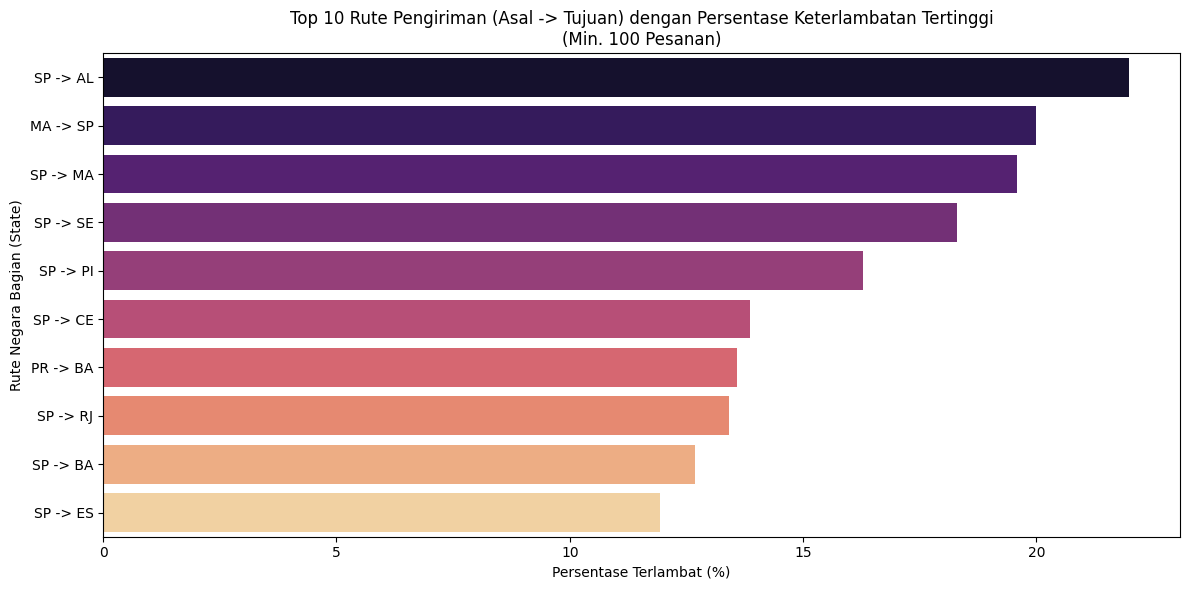

In [5]:
# 1. Memuat dataset lokasi pelanggan dan penjual
customers_path = 'archive/olist_customers_dataset.csv'
sellers_path = 'archive/olist_sellers_dataset.csv'

df_customers = pd.read_csv(customers_path)
df_sellers = pd.read_csv(sellers_path)

# Menggabungkan df_root_cause dengan data lokasi
df_geo = pd.merge(df_root_cause, df_customers[['customer_id', 'customer_state']], on='customer_id', how='left')
df_geo = pd.merge(df_geo, df_sellers[['seller_id', 'seller_state']], on='seller_id', how='left')

# Membuat kolom rute (Asal -> Tujuan)
df_geo['delivery_route'] = df_geo['seller_state'] + " -> " + df_geo['customer_state']

# 2. Analisis Rute Terburuk
# Kita hitung total pesanan dan total pesanan terlambat per rute
route_stats = df_geo.groupby('delivery_route').agg(
    total_orders=('order_id', 'count'),
    late_orders=('delivery_status', lambda x: (x == 'Terlambat').sum())
).reset_index()

# Menghitung persentase keterlambatan
route_stats['late_percentage'] = (route_stats['late_orders'] / route_stats['total_orders']) * 100

# Filter hanya rute dengan minimal 100 pesanan agar statistiknya valid
route_stats_filtered = route_stats[route_stats['total_orders'] >= 100]

# Mengurutkan 10 rute dengan persentase keterlambatan tertinggi
top_worst_routes = route_stats_filtered.sort_values(by='late_percentage', ascending=False).head(10)

# 3. Visualisasi Rute Terburuk
plt.figure(figsize=(12, 6))
sns.barplot(data=top_worst_routes, x='late_percentage', y='delivery_route', palette='magma')
plt.title('Top 10 Rute Pengiriman (Asal -> Tujuan) dengan Persentase Keterlambatan Tertinggi\n(Min. 100 Pesanan)')
plt.xlabel('Persentase Terlambat (%)')
plt.ylabel('Rute Negara Bagian (State)')
plt.tight_layout()
plt.show()

# Langkah 5: Pemodelan Prediktif (Machine Learning)

Pada tahap ini, kita akan membuat model Machine Learning untuk memprediksi apakah seorang pelanggan akan memberikan ulasan buruk (Bintang 1 atau 2).
Kita akan menggunakan kombinasi fitur-fitur seperti lama pengiriman, harga barang, ongkos kirim, dan volume barang.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df_ml = df_geo.copy()
df_ml['bad_review'] = np.where(df_ml['review_score'] <= 2, 1, 0)


df_ml = pd.merge(df_ml, df_products[['product_id', 'product_length_cm', 'product_height_cm', 'product_width_cm']], on='product_id', how='left')


df_ml['product_volume_cm3'] = df_ml['product_length_cm'] * df_ml['product_height_cm'] * df_ml['product_width_cm']

# Memilih fitur-fitur numerik yang akan digunakan
features = ['seller_processing_days', 'courier_delivery_days', 'freight_value', 'price', 'product_volume_cm3']

# Menghapus baris yang memiliki nilai kosong pada fitur-fitur tersebut agar model tidak error
df_ml = df_ml.dropna(subset=features + ['bad_review']).copy()

X = df_ml[features]
y = df_ml['bad_review']

# 3. Pembagian Data (Train-Test Split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah data latih: {X_train.shape[0]}")
print(f"Jumlah data uji: {X_test.shape[0]}")

Jumlah data latih: 86713
Jumlah data uji: 21679


Akurasi Keseluruhan: 0.893

Classification Report:
               precision    recall  f1-score   support

    Baik (0)       0.90      0.98      0.94     18466
   Buruk (1)       0.76      0.40      0.53      3213

    accuracy                           0.89     21679
   macro avg       0.83      0.69      0.73     21679
weighted avg       0.88      0.89      0.88     21679



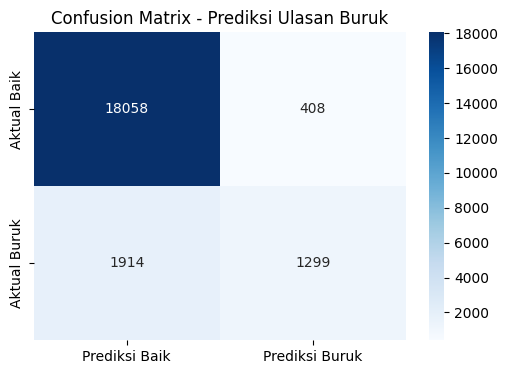

C:\Users\altha\AppData\Local\Temp\ipykernel_12592\1396892025.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importances, x='Kepentingan', y='Fitur', palette='viridis')


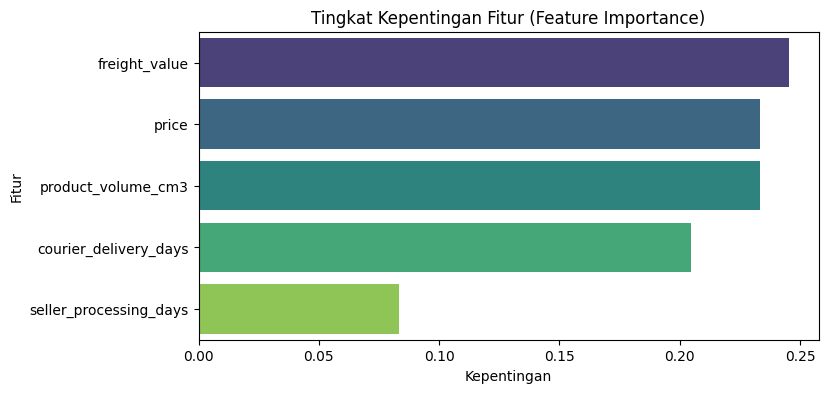

In [7]:
# 4. Pelatihan Model Random Forest
# Menggunakan class_weight='balanced' karena jumlah ulasan buruk pasti jauh lebih sedikit dibanding ulasan baik
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
rf_model.fit(X_train, y_train)

# 5. Evaluasi Model
y_pred = rf_model.predict(X_test)

print("Akurasi Keseluruhan:", round(accuracy_score(y_test, y_pred), 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['Baik (0)', 'Buruk (1)']))

# 6. Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Prediksi Baik', 'Prediksi Buruk'], yticklabels=['Aktual Baik', 'Aktual Buruk'])
plt.title('Confusion Matrix - Prediksi Ulasan Buruk')
plt.show()

# 7. Fitur mana yang paling penting?
feature_importances = pd.DataFrame({'Fitur': features, 'Kepentingan': rf_model.feature_importances_})
feature_importances = feature_importances.sort_values(by='Kepentingan', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=feature_importances, x='Kepentingan', y='Fitur', palette='viridis')
plt.title('Tingkat Kepentingan Fitur (Feature Importance)')
plt.show()

# Langkah 6: Analisis Teks (NLP Dasar) pada Keluhan Pelanggan

Sebagai penutup, mari kita lihat apa yang sebenarnya ditulis pelanggan ketika pesanan mereka terlambat.
Kita akan menggunakan teknik *Natural Language Processing* (NLP) dasar untuk menghitung frekuensi kata-kata yang paling sering muncul dari kolom `review_comment_message`.

C:\Users\altha\AppData\Local\Temp\ipykernel_12592\3470892423.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=words_df, x='Frekuensi', y='Kata', palette='Reds_r')


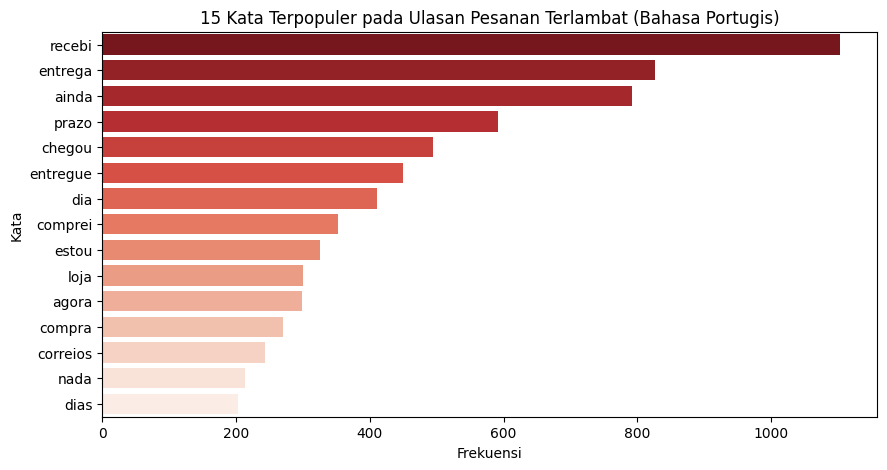

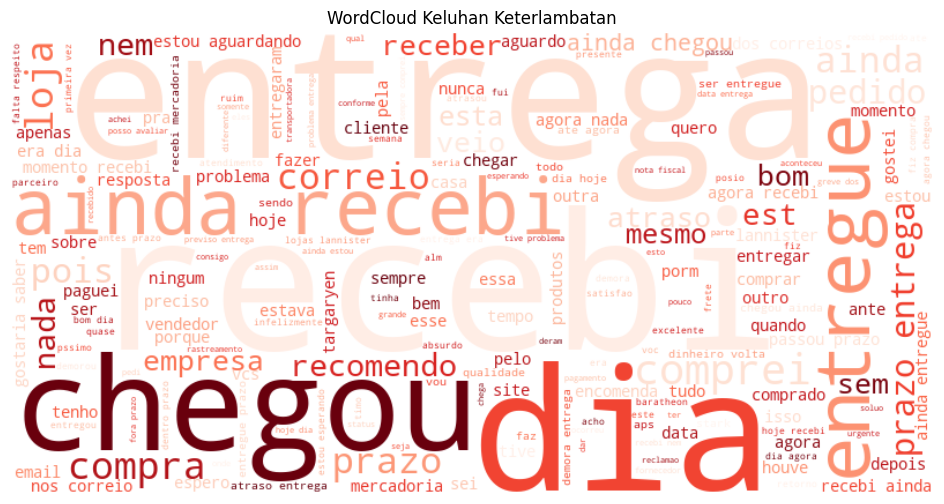

In [8]:
import re
from collections import Counter
from wordcloud import WordCloud

# 1. Filter ulasan teks hanya pada pesanan yang terlambat
df_text = df_clean[(df_clean['delivery_status'] == 'Terlambat') & (df_clean['review_comment_message'].notnull())].copy()

# 2. Fungsi pembersihan teks sederhana (merubah ke huruf kecil, menghapus angka dan tanda baca)
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text) # Hanya menyisakan huruf dan spasi
    return text

df_text['cleaned_review'] = df_text['review_comment_message'].apply(clean_text)

# 3. Kumpulan kata berhenti (stopwords) bahasa Portugis sederhana (karena Olist dari Brasil)
portuguese_stopwords = set(['o', 'a', 'os', 'as', 'um', 'uma', 'e', 'que', 'do', 'da', 'de', 'no', 'na', 
                            'com', 'para', 'por', 'como', 'mais', 'mas', 'foi', 'ao', 'ele', 'ela', 
                            'eu', 'meu', 'minha', 'muito', 'não', 'nao', 'já', 'ja', 'é', 'está', 'produto'])

# 4. Ekstraksi kata-kata
all_words = []
for review in df_text['cleaned_review']:
    words = review.split()
    words = [word for word in words if word not in portuguese_stopwords and len(word) > 2]
    all_words.extend(words)

# Hitung frekuensi 15 kata terbanyak
word_freq = Counter(all_words)
common_words = word_freq.most_common(15)

words_df = pd.DataFrame(common_words, columns=['Kata', 'Frekuensi'])

# 5. Visualisasi 1: Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(data=words_df, x='Frekuensi', y='Kata', palette='Reds_r')
plt.title('15 Kata Terpopuler pada Ulasan Pesanan Terlambat (Bahasa Portugis)')
plt.show()

# 6. Visualisasi 2: WordCloud
text_for_wordcloud = " ".join(all_words)
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(text_for_wordcloud)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Keluhan Keterlambatan')
plt.show()
